<a href="https://colab.research.google.com/github/readytocommit/FinalProject/blob/main/colored_image_classification_mit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Set a set for a same randomness

keras.utils.set_random_seed(42)

In [6]:
#Linux command for downloading and unziping the file

!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
!unzip -qq handbags-shoes.zip

In [7]:
#Data PreProcessing

"""
Is deep learning even possible with so few examples ? -> Yes We can build near perfect handbags vs shoes classifier with just these
200 images.

"""

'\nIs deep learning even possible with so few examples ? -> Yes We can build near perfect handbags vs shoes classifier with just these\n200 images.\n\n'

In [8]:
#Since this is not a Keras standard dataset, we will need to split it into train/validation/test sets ourselves

In [12]:
import os, pathlib, shutil

base_dir = pathlib.Path("/content/handbags-shoes")

In [13]:
for category in ('handbags','shoes'):
  fnames = os.listdir(base_dir/category)
  dir = base_dir/'train'/category
  os.makedirs(dir)
  for fname in fnames[:50]:
    shutil.copyfile(src = base_dir/category/fname, dst=dir/fname)


  dir = base_dir/'validation'/category
  os.makedirs(dir)
  for fname in fnames[50:75]:
    shutil.copyfile(src = base_dir/category/fname, dst=dir/fname)


  dir = base_dir/'test'/category
  os.makedirs(dir)
  for fname in fnames[75:]:
    shutil.copyfile(src = base_dir/category/fname, dst=dir/fname)

In [16]:
#When working with image JPEGs, we will follow this process:

#Read images in JPEGS or other forms..
#Convert JPEGs into tensors
#Resize them to a standard size (since web-scraped images may be different)
# Group them into batches (we'll use batches of 32 images)

# Keras gives us a single function that does all these in one shot.

train_dataset = keras.utils.image_dataset_from_directory(
    base_dir/ 'train',
    image_size = (224,224),
    batch_size = 32
)

vaidation_dataset = keras.utils.image_dataset_from_directory(
    base_dir/ 'validation',
    image_size = (224,224),
    batch_size = 32
)

test_dataset = keras.utils.image_dataset_from_directory(
    base_dir/ 'test',
    image_size = (224,224),
    batch_size = 32
)




Found 98 files belonging to 2 classes.
Found 47 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [18]:
# Let's check the shape of the image. Since these are color images, they will have 3 channels and sice we sized them to (224,224), the
# shape should be (224,224,3)

for images, _ in train_dataset.take(1):
  print(images[0].shape)


(224, 224, 3)


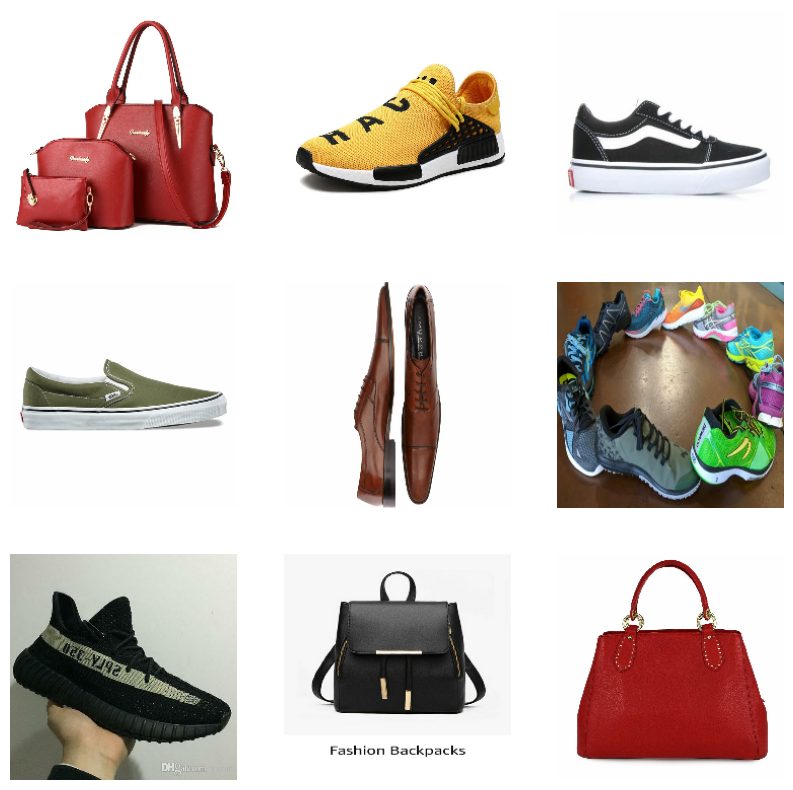

In [19]:
plt.figure(figsize= (10,10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

In [20]:
# A basic convulational network

input = keras.Input(shape = (224,224,3))

#we normalize "inside" the model with Rescaling layer
# so we dont have to remember to do it every time.
# we need to use the model to make a prediction

h = keras.layers.Rescaling(1./255)(input)


#first convulation block

h = keras.layers.Conv2D(
    32, #number of filters,
    kernel_size = (2,2), # The size of each filter
    activation = "relu",
    name = "Conv_1"
)(h)

#The pooling layer

h = keras.layers.MaxPool2D()(h)

#second convulational layer

h = keras.layers.Conv2D(
    32, # number of filters
    kernel_size = (2,2), # The size of each filter
    activation = "relu",
    name = "conv_2"
)(h)

#The second Pooling layer

h = keras.layers.MaxPool2D()(h)

#flatten layer

h = keras.layers.Flatten()(h)

#Output layer

output = keras.layers.Dense(1,activation= "sigmoid")(h)

model = keras.Model(input,output)




In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        96,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,345 (395.88 KB)

 Trainable params: 101,345 (395.88 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [23]:
#Now lets train the model

history = model.fit(train_dataset,epochs=20,validation_data= vaidation_dataset)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4592 - loss: 1.0887 - val_accuracy: 0.6383 - val_loss: 0.6039
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.5918 - loss: 0.7360 - val_accuracy: 0.5319 - val_loss: 0.6683
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.7245 - loss: 0.5513 - val_accuracy: 0.5319 - val_loss: 0.7496
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.5204 - loss: 0.6333 - val_accuracy: 0.7872 - val_loss: 0.5240
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.8265 - loss: 0.4620 - val_accuracy: 0.8085 - val_loss: 0.5023
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - accuracy: 0.8980 - loss: 0.3739 - val_accuracy: 0.6170 - val_loss: 0.5613
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.8265 - loss: 0.3803 - val_accuracy: 0.8723 - val_loss: 0.4012
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.9388 - loss: 0.2761 - val_accuracy: 0.8723 - val_loss: 0.

In [34]:
def plot_loss_curves(history):


  hist_dict = history.history
  loss_values = hist_dict["loss"]
  val_loss_values = hist_dict["val_loss"]
  epochs = range(1,len(loss_values)+1)
  plt.plot(epochs,loss_values,"bo",label = "Training Loss")
  plt.plot(epochs,val_loss_values,"b",label= "Validation Loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Losses")
  plt.legend()
  plt.show()


def plot_accuracy(history):


  hist_dict = history.history
  acc = hist_dict["accuracy"]
  val_accuracy = hist_dict["val_accuracy"]
  epochs = range(1,len(acc)+1)
  plt.plot(epochs,acc,"bo",label = "Training LAccuracy")
  plt.plot(epochs,val_accuracy,"b",label= "Validation Accuracy")
  plt.title("Training and validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

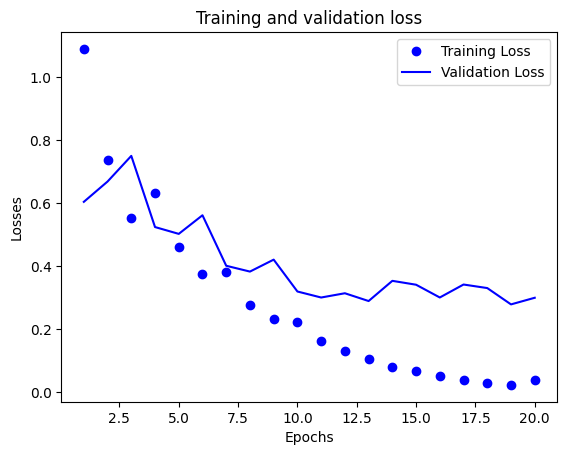

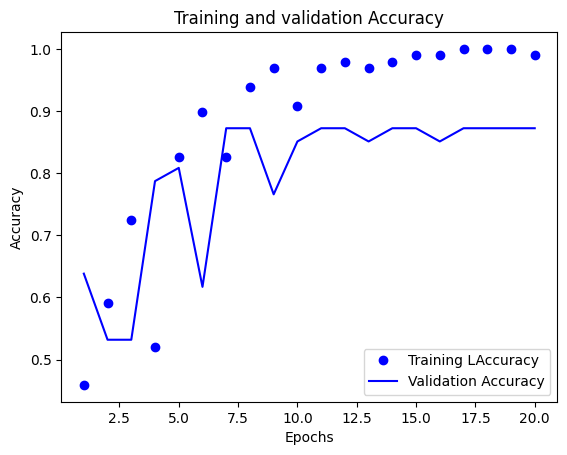

In [35]:
plot_loss_curves(history)
plot_accuracy(history)

In [36]:
model.evaluate(test_dataset)

#Its okay even with a small number of datasets

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - accuracy: 0.8000 - loss: 0.4873


[0.48728352785110474, 0.800000011920929]

In [26]:
# Can we do better ? We only have 100 examples of each class


# Transfer learning with Pre-Trained Networks


# Transfer learning takes advantage of two research trends

# Trend 1 : Researches have designed NN architectures that are well-matched to different types of data. For example:

# Type of data    =========================================== Architecture

# All                                                        Residual connections
# Images                                                     Convulational layers
# Sequences (e.g, natural language                           Transformers
# audio, video, gene sequences )

# Trend 2: Using these architectural innovations, researchers have trained high-performance DNNs on a variety of large real-world datasets.
# Numerous pretrained models are available.

# Transfer learning involves customizing such a pre-trained network to your problem, rather than designing and trainig a network from a scratch

In [28]:
# ====== ** Can we apply Transfer Learning to build a better Handbags/Shoes Classifier ? ** ======

# Handbags and shoes are everday objects and you can look around and see if there are any networks that have been trained on a dataset of images
# of "everyday objects"

# ImageNet dataset has millions of images of 100 categories of everyday objects. We can look for networks that hav been trained on ImageNet